# GraphSAGE Hyperparameter Tuning

This notebook implements a distributed hyperparameter search for the GraphSAGE quantum error correction model.

**Aggregation:** Using `mean` and `max` only (LSTM removed due to 4x slower training time).

**Workflow:**
1. Set `WORKER_ID` below (1-5), or use `CUSTOM_CONFIGS` to specify exact config IDs
2. Run the training loop to train the assigned configurations
3. After all workers complete, run the analysis cells

**Configuration Options:**
- `WORKER_ID`: Use worker-based assignment (1-5), each gets 10 configs via modulo-5
- `CUSTOM_CONFIGS`: Override with a custom list of config IDs to train in that order, e.g., `[5, 12, 23, 7]`

**Worker Assignment (50 configs total, 10 per worker):**
- Worker 1: configs where `id % 5 == 0` → [0, 5, 10, 15, 20, 25, 30, 35, 40, 45]
- Worker 2: configs where `id % 5 == 1` → [1, 6, 11, 16, 21, 26, 31, 36, 41, 46]
- Worker 3: configs where `id % 5 == 2` → [2, 7, 12, 17, 22, 27, 32, 37, 42, 47]
- Worker 4: configs where `id % 5 == 3` → [3, 8, 13, 18, 23, 28, 33, 38, 43, 48]
- Worker 5: configs where `id % 5 == 4` → [4, 9, 14, 19, 24, 29, 34, 39, 44, 49]

In [1]:
#==============================================================================
# CONFIGURATION
#==============================================================================
WORKER_ID = 1  # Set to 1, 2, 3, 4, or 5 for each Colab instance

# Optional: specify custom config IDs to train (in order). If set, overrides WORKER_ID assignment.
CUSTOM_CONFIGS = []  # e.g., [5, 12, 23, 7] to train those configs in that order
#==============================================================================

# Determine which configs to train
if CUSTOM_CONFIGS:
    my_config_ids = CUSTOM_CONFIGS
    print(f"Using CUSTOM_CONFIGS: {my_config_ids}")
else:
    # Validate worker ID
    assert WORKER_ID in [1, 2, 3, 4, 5], f"WORKER_ID must be 1, 2, 3, 4, or 5, got {WORKER_ID}"
    # Uniform modulo-5 distribution
    my_config_ids = [i for i in range(50) if i % 5 == (WORKER_ID - 1)]
    print(f"Worker ID: {WORKER_ID}")

print(f"This worker will train {len(my_config_ids)} configs: {my_config_ids}")

Worker ID: 1
This worker will train 10 configs: [0, 5, 10, 15, 20, 25, 30, 35, 40, 45]


#### Imports

In [1]:
# Install required libraries (uncomment and run if needed)
!pip install stim pymatching numpy matplotlib torch tqdm networkx
!pip install torch_geometric

# For CUDA support with PyTorch Geometric, you may need:
# !pip install torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.0.0+cu118.html


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import sys
import json
import random
import time
from pathlib import Path
from datetime import datetime

# Detect if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/Research/QEC/quantum-error-correction/quantum-error-correction/code')
else:
    BASE_PATH = Path('../..')

sys.path.insert(0, str(BASE_PATH))

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from torch_geometric.loader import DataLoader

# Import from models.py
from models import (
    SurfaceCodeSampler,
    SparseGraph,
    GraphSAGEModel,
    GraphSAGE,
    DatasetCache,
)

# Set up paths
TUNING_DIR = BASE_PATH / "gSAGE" / "tuning"
TUNING_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = TUNING_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = TUNING_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = TUNING_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print(f"\nPaths:")
print(f"  BASE_PATH: {BASE_PATH}")
print(f"  TUNING_DIR: {TUNING_DIR}")
print(f"  RESULTS_DIR: {RESULTS_DIR}")
print(f"  MODELS_DIR: {MODELS_DIR}")

C:\Users\Bill\AppData\Roaming\Python\Python313\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
C:\Users\Bill\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti

Paths:
  BASE_PATH: ..\..
  TUNING_DIR: ..\..\gSAGE\tuning
  RESULTS_DIR: ..\..\gSAGE\tuning\results
  MODELS_DIR: ..\..\gSAGE\tuning\models


#### Generate Configs (ALREADY RUN)

Config generation has been completed. 50 configurations using `mean` and `max` aggregation only (LSTM removed).
The `configs.json` file already exists - this cell is for reference only.

In [ ]:
# # =============================================================================
# # CONFIG GENERATION - RUN ONCE ON ANY INSTANCE
# # =============================================================================

# CONFIGS_PATH = TUNING_DIR / "configs.json"

# # Check if configs already exist
# if CONFIGS_PATH.exists():
#     print(f"configs.json already exists at {CONFIGS_PATH}")
#     print("Skipping generation. Delete the file to regenerate.")
# else:
#     # Search space definition (LSTM removed - too slow)
#     SEARCH_SPACE = {
#         'num_layers': [2, 3, 4, 5],
#         'hidden_dim': [64, 128, 256, 512],
#         'learning_rate': [1e-4, 3e-4, 5e-4, 1e-3, 3e-3],
#         'dropout': [0.0, 0.1, 0.2, 0.3],
#         'aggr': ['mean', 'max']
#     }

#     # Fixed parameters (not searched)
#     FIXED_PARAMS = {
#         'batch_size': 256,
#         'epochs': 50,
#         'distance': 7,
#         'in_channels': 5
#     }

#     # Number of configurations to generate
#     N_CONFIGS = 50  
#     SEED = 42

#     # Set seed for reproducibility
#     random.seed(SEED)

#     # Generate random configurations
#     configs = []
#     for i in range(N_CONFIGS):
#         config = {
#             'id': i,
#             'num_layers': random.choice(SEARCH_SPACE['num_layers']),
#             'hidden_dim': random.choice(SEARCH_SPACE['hidden_dim']),
#             'learning_rate': random.choice(SEARCH_SPACE['learning_rate']),
#             'dropout': random.choice(SEARCH_SPACE['dropout']),
#             'aggr': random.choice(SEARCH_SPACE['aggr'])
#         }
#         configs.append(config)

#     # Create the full config document
#     config_doc = {
#         'seed': SEED,
#         'n_configs': N_CONFIGS,
#         'generated_at': datetime.now().isoformat(),
#         'search_space': SEARCH_SPACE,
#         'fixed_params': FIXED_PARAMS,
#         'configs': configs
#     }

#     # Save to file
#     with open(CONFIGS_PATH, 'w') as f:
#         json.dump(config_doc, f, indent=2)

#     print(f"Generated {N_CONFIGS} configurations with seed {SEED}")
#     print(f"Saved to: {CONFIGS_PATH}")
#     print(f"\nSearch space:")
#     for key, values in SEARCH_SPACE.items():
#         print(f"  {key}: {values}")
#     print(f"\nFixed parameters:")
#     for key, value in FIXED_PARAMS.items():
#         print(f"  {key}: {value}")
#     print(f"\nFirst 5 configs:")
#     for c in configs[:5]:
#         print(f"  {c}")

Generated 50 configurations with seed 42
Saved to: ..\..\gSAGE\tuning\configs.json

Search space:
  num_layers: [2, 3, 4, 5]
  hidden_dim: [64, 128, 256, 512]
  learning_rate: [0.0001, 0.0003, 0.0005, 0.001, 0.003]
  dropout: [0.0, 0.1, 0.2, 0.3]
  aggr: ['mean', 'max']

Fixed parameters:
  batch_size: 256
  epochs: 50
  distance: 7
  in_channels: 5

First 5 configs:
  {'id': 0, 'num_layers': 2, 'hidden_dim': 64, 'learning_rate': 0.0005, 'dropout': 0.1, 'aggr': 'mean'}
  {'id': 1, 'num_layers': 3, 'hidden_dim': 64, 'learning_rate': 0.003, 'dropout': 0.0, 'aggr': 'max'}
  {'id': 2, 'num_layers': 2, 'hidden_dim': 64, 'learning_rate': 0.0001, 'dropout': 0.1, 'aggr': 'mean'}
  {'id': 3, 'num_layers': 2, 'hidden_dim': 128, 'learning_rate': 0.003, 'dropout': 0.3, 'aggr': 'mean'}
  {'id': 4, 'num_layers': 5, 'hidden_dim': 256, 'learning_rate': 0.0001, 'dropout': 0.1, 'aggr': 'max'}


#### Training Loop

This is the main training cell. It will:
1. Load the configs assigned to this worker
2. Skip any configs already completed (for resume support)
3. Train each config and save results incrementally

In [ ]:
# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def load_configs():
    """Load all configurations from configs.json."""
    configs_path = TUNING_DIR / "configs.json"
    if not configs_path.exists():
        raise FileNotFoundError(f"configs.json not found at {configs_path}. Run the config generation cell first.")
    with open(configs_path, 'r') as f:
        return json.load(f)

def get_worker_configs(all_configs, worker_id):
    """Get configs assigned to this worker using modulo-5 assignment."""
    return [c for c in all_configs['configs'] if c['id'] % 5 == (worker_id - 1)]

def get_completed_ids(worker_id):
    """Get set of already-completed config IDs for this worker."""
    results_path = RESULTS_DIR / f"worker_{worker_id}.json"
    if not results_path.exists():
        return set()
    with open(results_path, 'r') as f:
        results = json.load(f)
    return {r['config_id'] for r in results if r.get('status') == 'completed'}

def save_result(result, worker_id):
    """Append a result to this worker's results file."""
    results_path = RESULTS_DIR / f"worker_{worker_id}.json"

    # Load existing results
    if results_path.exists():
        with open(results_path, 'r') as f:
            results = json.load(f)
    else:
        results = []

    # Append new result
    results.append(result)

    # Save back
    with open(results_path, 'w') as f:
        json.dump(results, f, indent=2)

    return len(results)

def evaluate_model(model, graphs, device):
    """Evaluate model accuracy on a set of graphs."""
    model.model.eval()
    loader = DataLoader(graphs, batch_size=256, shuffle=False)

    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model.model(batch)
            y = batch.y.float().view(-1, 1)
            correct += ((pred > 0.5).float() == y).sum().item()
            total += y.size(0)

    return correct / total if total > 0 else 0.0

def load_and_split_dataset(cache_name, train_ratio=0.8, val_ratio=0.1, seed=42):
    """Load dataset from cache and split into train/val/test."""
    print(f"Loading dataset: {cache_name}")
    cache = DatasetCache(base_path=BASE_PATH, device=device)
    cache.load(cache_name, verbose=True)
    graphs = cache.get_graphs()

    # Shuffle with fixed seed for reproducibility
    random.seed(seed)
    indices = list(range(len(graphs)))
    random.shuffle(indices)

    # Calculate split points
    n = len(graphs)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    # Split
    train_idx = indices[:train_end]
    val_idx = indices[train_end:val_end]
    test_idx = indices[val_end:]

    train_graphs = [graphs[i] for i in train_idx]
    val_graphs = [graphs[i] for i in val_idx]
    test_graphs = [graphs[i] for i in test_idx]

    print(f"Dataset split: {len(train_graphs)} train, {len(val_graphs)} val, {len(test_graphs)} test")

    return train_graphs, val_graphs, test_graphs

In [ ]:
# =============================================================================
# MAIN TRAINING LOOP
# =============================================================================

import gc

# Load all configurations
all_configs = load_configs()
fixed_params = all_configs['fixed_params']

# Get configs to train (uses my_config_ids from configuration cell)
# This respects both WORKER_ID assignment and CUSTOM_CONFIGS override
config_id_set = set(my_config_ids)
my_configs = [c for c in all_configs['configs'] if c['id'] in config_id_set]
# Preserve the order specified in my_config_ids
my_configs = sorted(my_configs, key=lambda c: my_config_ids.index(c['id']))

print(f"\nConfigs to train: {len(my_configs)}")
print(f"Config IDs (in order): {[c['id'] for c in my_configs]}")

# Check which are already completed
completed_ids = get_completed_ids(WORKER_ID)
remaining_configs = [c for c in my_configs if c['id'] not in completed_ids]
print(f"\nAlready completed: {len(completed_ids)} configs")
print(f"Remaining: {len(remaining_configs)} configs")

if len(remaining_configs) == 0:
    print("\nAll configs are already completed!")
else:
    # Load dataset once (shared across all configs)
    cache_name = f"d{fixed_params['distance']}_baseline"
    train_graphs, val_graphs, test_graphs = load_and_split_dataset(cache_name)

In [ ]:
if len(remaining_configs) > 0:
    print(f"\n{'='*60}")
    print(f"Starting training for Worker {WORKER_ID}")
    print(f"{'='*60}")

    for i, config in enumerate(remaining_configs):
        config_id = config['id']
        print(f"\n{'='*60}")
        print(f"Config {config_id} ({i+1}/{len(remaining_configs)})")
        print(f"{'='*60}")
        print(f"Parameters:")
        print(f"  num_layers: {config['num_layers']}")
        print(f"  hidden_dim: {config['hidden_dim']}")
        print(f"  learning_rate: {config['learning_rate']}")
        print(f"  dropout: {config['dropout']}")
        print(f"  aggr: {config['aggr']}")

        start_time = time.time()

        try:
            # Initialize model with config hyperparameters
            model = GraphSAGE(
                nickname=f"config_{config_id}",
                in_channels=fixed_params['in_channels'],
                hidden_dim=config['hidden_dim'],
                num_layers=config['num_layers'],
                dropout=config['dropout'],
                aggr=config['aggr'],
                device=device,
                base_path=BASE_PATH,
                seed=config_id  # Use config_id as seed for reproducibility
            )

            # Train the model
            epoch_losses = model.train(
                graphs=train_graphs,
                epochs=fixed_params['epochs'],
                batch_size=fixed_params['batch_size'],
                lr=config['learning_rate'],
                verbose=True
            )

            # Evaluate on validation and test sets
            val_accuracy = evaluate_model(model, val_graphs, device)
            test_accuracy = evaluate_model(model, test_graphs, device)

            training_time = time.time() - start_time

            # Save the model to tuning/models/
            model_path = MODELS_DIR / f"config_{config_id}.pt"
            save_dict = {
                'state_dict': model.model.state_dict(),
                'config': model._config,
                'hyperparams': config,
                'val_accuracy': val_accuracy,
                'test_accuracy': test_accuracy,
                'training_time_sec': training_time,
                'timestamp': datetime.now().isoformat()
            }
            torch.save(save_dict, model_path)
            print(f"\nModel saved to: {model_path}")

            # Create result record
            result = {
                'config_id': config_id,
                'config': config,
                'val_accuracy': val_accuracy,
                'test_accuracy': test_accuracy,
                'training_time_sec': training_time,
                'final_loss': epoch_losses[-1] if epoch_losses else None,
                'model_path': str(model_path),
                'status': 'completed',
                'timestamp': datetime.now().isoformat()
            }

            print(f"\nResults:")
            print(f"  Val Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
            print(f"  Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
            print(f"  Training Time: {training_time:.1f}s ({training_time/60:.1f} min)")

        except Exception as e:
            training_time = time.time() - start_time
            print(f"\nERROR: Config {config_id} failed: {str(e)}")
            import traceback
            traceback.print_exc()
            result = {
                'config_id': config_id,
                'config': config,
                'val_accuracy': None,
                'test_accuracy': None,
                'training_time_sec': training_time,
                'final_loss': None,
                'model_path': None,
                'status': 'failed',
                'error': str(e),
                'timestamp': datetime.now().isoformat()
            }
            # Cleanup on error too
            if 'model' in dir():
                del model

        # Save result incrementally
        n_saved = save_result(result, WORKER_ID)
        print(f"Result saved ({n_saved} total for this worker)")

        # Aggressive cleanup to prevent RAM/VRAM from filling up
        if 'model' in dir():
            del model
        if 'epoch_losses' in dir():
            del epoch_losses
        if 'save_dict' in dir():
            del save_dict

        # Force garbage collection
        gc.collect()

        # Clear CUDA cache if available
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()

        print(f"Memory cleared.")

    print(f"\n{'='*60}")
    print(f"Worker {WORKER_ID} COMPLETE!")
    print(f"{'='*60}")
    print(f"Total configs trained: {len(remaining_configs)}")
    print(f"Results saved to: {RESULTS_DIR / f'worker_{WORKER_ID}.json'}")
    print(f"Models saved to: {MODELS_DIR}")

#### Combine Results (RUN AFTER ALL WORKERS COMPLETE)

This cell combines results from all 5 workers into a single CSV file and identifies the best configurations.

In [3]:
# # =============================================================================
# # COMBINE RESULTS FROM ALL WORKERS
# # =============================================================================

# def combine_all_results():
#     """Load and combine results from all 5 workers."""
#     all_results = []

#     for worker_id in [1, 2, 3, 4, 5]:
#         results_path = RESULTS_DIR / f"worker_{worker_id}.json"
#         if results_path.exists():
#             with open(results_path, 'r') as f:
#                 worker_results = json.load(f)
#             all_results.extend(worker_results)
#             print(f"Worker {worker_id}: {len(worker_results)} results")
#         else:
#             print(f"Worker {worker_id}: No results file found")

#     return all_results

# # Combine results
# print("Combining results from all workers...")
# all_results = combine_all_results()

# # Deduplicate: keep best result per config_id (by val_accuracy)
# if len(all_results) > 0:
#     from collections import defaultdict
#     results_by_config = defaultdict(list)
#     for r in all_results:
#         results_by_config[r['config_id']].append(r)
    
#     # Keep best result for each config
#     deduped_results = []
#     duplicates_found = 0
#     for config_id, results in results_by_config.items():
#         if len(results) > 1:
#             duplicates_found += len(results) - 1
#             # Keep best by val_accuracy (completed only)
#             completed = [r for r in results if r.get('status') == 'completed']
#             if completed:
#                 best = max(completed, key=lambda r: r.get('val_accuracy', 0))
#             else:
#                 best = results[0]
#         else:
#             best = results[0]
#         deduped_results.append(best)
    
#     print(f"Duplicates removed: {duplicates_found}")
#     all_results = deduped_results

# # Filter to completed only
# completed_results = [r for r in all_results if r.get('status') == 'completed']
# failed_results = [r for r in all_results if r.get('status') == 'failed']

# print(f"\nTotal results: {len(all_results)}")
# print(f"  Completed: {len(completed_results)}")
# print(f"  Failed: {len(failed_results)}")

# if len(completed_results) > 0:
#     # Create DataFrame
#     df = pd.DataFrame(completed_results)

#     # Flatten config dict into columns
#     config_df = pd.json_normalize(df['config'])
#     config_df.columns = [f"hp_{col}" for col in config_df.columns]
#     df = pd.concat([df.drop('config', axis=1), config_df], axis=1)

#     # Sort by validation accuracy
#     df = df.sort_values('val_accuracy', ascending=False).reset_index(drop=True)

#     # Save to CSV
#     csv_path = TUNING_DIR / "combined_results.csv"
#     df.to_csv(csv_path, index=False)
#     print(f"\nResults saved to: {csv_path}")

#     # Print top 5 configurations
#     print(f"\n{'='*60}")
#     print("TOP 5 CONFIGURATIONS (by validation accuracy)")
#     print(f"{'='*60}")

#     for i, row in df.head(5).iterrows():
#         print(f"\n#{i+1} - Config {row['config_id']}")
#         print(f"  Val Accuracy:  {row['val_accuracy']:.4f} ({row['val_accuracy']*100:.2f}%)")
#         print(f"  Test Accuracy: {row['test_accuracy']:.4f} ({row['test_accuracy']*100:.2f}%)")
#         print(f"  Training Time: {row['training_time_sec']:.1f}s")
#         print(f"  Hyperparameters:")
#         print(f"    num_layers: {row['hp_num_layers']}")
#         print(f"    hidden_dim: {row['hp_hidden_dim']}")
#         print(f"    learning_rate: {row['hp_learning_rate']}")
#         print(f"    dropout: {row['hp_dropout']}")
#         print(f"    aggr: {row['hp_aggr']}")

#     # Best configuration summary
#     best = df.iloc[0]
#     print(f"\n{'='*60}")
#     print("BEST CONFIGURATION")
#     print(f"{'='*60}")
#     print(f"Config ID: {best['config_id']}")
#     print(f"Val Accuracy: {best['val_accuracy']:.4f}")
#     print(f"Test Accuracy: {best['test_accuracy']:.4f}")
#     print(f"\nHyperparameters for production use:")
#     print(f"  num_layers = {best['hp_num_layers']}")
#     print(f"  hidden_dim = {best['hp_hidden_dim']}")
#     print(f"  learning_rate = {best['hp_learning_rate']}")
#     print(f"  dropout = {best['hp_dropout']}")
#     print(f"  aggr = '{best['hp_aggr']}'")

#     # Overall statistics
#     print(f"\n{'='*60}")
#     print("OVERALL STATISTICS")
#     print(f"{'='*60}")
#     print(f"Val Accuracy:  mean={df['val_accuracy'].mean():.4f}, std={df['val_accuracy'].std():.4f}")
#     print(f"Test Accuracy: mean={df['test_accuracy'].mean():.4f}, std={df['test_accuracy'].std():.4f}")
#     print(f"Training Time: mean={df['training_time_sec'].mean():.1f}s, total={df['training_time_sec'].sum()/3600:.1f}h")
# else:
#     print("\nNo completed results to analyze.")

Combining results from all workers...
Worker 1: 19 results
Worker 2: 12 results
Worker 3: 12 results
Worker 4: 10 results
Worker 5: 10 results
Duplicates removed: 13

Total results: 50
  Completed: 50
  Failed: 0

Results saved to: ..\gSAGE\tuning\combined_results.csv

TOP 5 CONFIGURATIONS (by validation accuracy)

#1 - Config 17
  Val Accuracy:  0.9022 (90.22%)
  Test Accuracy: 0.9028 (90.28%)
  Training Time: 2271.3s
  Hyperparameters:
    num_layers: 5
    hidden_dim: 128
    learning_rate: 0.0005
    dropout: 0.0
    aggr: max

#2 - Config 43
  Val Accuracy:  0.8935 (89.35%)
  Test Accuracy: 0.8937 (89.37%)
  Training Time: 8294.9s
  Hyperparameters:
    num_layers: 5
    hidden_dim: 512
    learning_rate: 0.0003
    dropout: 0.0
    aggr: mean

#3 - Config 25
  Val Accuracy:  0.8878 (88.78%)
  Test Accuracy: 0.8882 (88.82%)
  Training Time: 1851.1s
  Hyperparameters:
    num_layers: 5
    hidden_dim: 64
    learning_rate: 0.001
    dropout: 0.0
    aggr: mean

#4 - Config 1
  Val 

#### Analysis & Visualization

Generate plots to understand hyperparameter importance and find patterns.

Loaded 25 results from ..\..\gSAGE\tuning\combined_results.csv


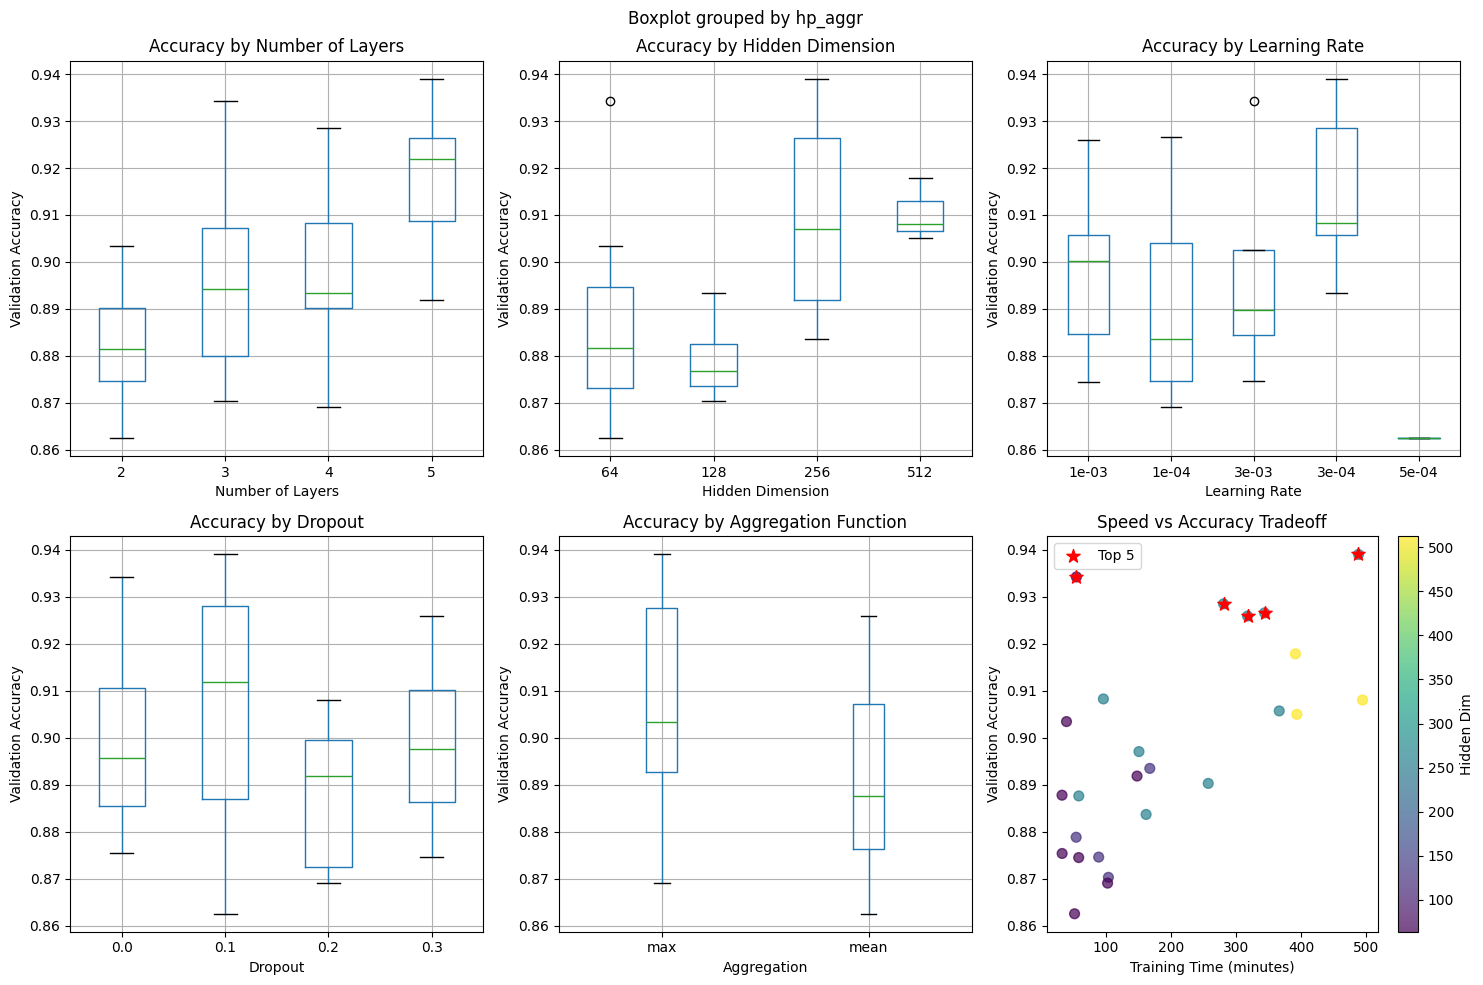


Plot saved to: ..\..\gSAGE\tuning\plots\hyperparameter_analysis.png


In [3]:
# =============================================================================
# ANALYSIS & VISUALIZATION
# =============================================================================

# Load results if not already loaded
if 'df' not in dir() or df is None:
    csv_path = TUNING_DIR / "combined_results.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        print(f"Loaded {len(df)} results from {csv_path}")
    else:
        raise FileNotFoundError("Run the combine results cell first!")

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('GraphSAGE Hyperparameter Tuning Analysis', fontsize=14, fontweight='bold')

# 1. Box plot: Validation accuracy by num_layers
ax = axes[0, 0]
df.boxplot(column='val_accuracy', by='hp_num_layers', ax=ax)
ax.set_title('Accuracy by Number of Layers')
ax.set_xlabel('Number of Layers')
ax.set_ylabel('Validation Accuracy')
plt.sca(ax)
plt.xticks(rotation=0)

# 2. Box plot: Validation accuracy by hidden_dim
ax = axes[0, 1]
df.boxplot(column='val_accuracy', by='hp_hidden_dim', ax=ax)
ax.set_title('Accuracy by Hidden Dimension')
ax.set_xlabel('Hidden Dimension')
ax.set_ylabel('Validation Accuracy')

# 3. Box plot: Validation accuracy by learning_rate
ax = axes[0, 2]
# Format learning rates for display
df['lr_label'] = df['hp_learning_rate'].apply(lambda x: f'{x:.0e}')
df.boxplot(column='val_accuracy', by='lr_label', ax=ax)
ax.set_title('Accuracy by Learning Rate')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Validation Accuracy')

# 4. Box plot: Validation accuracy by dropout
ax = axes[1, 0]
df.boxplot(column='val_accuracy', by='hp_dropout', ax=ax)
ax.set_title('Accuracy by Dropout')
ax.set_xlabel('Dropout')
ax.set_ylabel('Validation Accuracy')

# 5. Box plot: Validation accuracy by aggregation
ax = axes[1, 1]
df.boxplot(column='val_accuracy', by='hp_aggr', ax=ax)
ax.set_title('Accuracy by Aggregation Function')
ax.set_xlabel('Aggregation')
ax.set_ylabel('Validation Accuracy')

# 6. Speed vs Accuracy tradeoff
ax = axes[1, 2]
scatter = ax.scatter(df['training_time_sec']/60, df['val_accuracy'],
                     c=df['hp_hidden_dim'], cmap='viridis', alpha=0.7, s=50)
ax.set_xlabel('Training Time (minutes)')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Speed vs Accuracy Tradeoff')
plt.colorbar(scatter, ax=ax, label='Hidden Dim')

# Mark top 5
top5 = df.head(5)
ax.scatter(top5['training_time_sec']/60, top5['val_accuracy'],
           c='red', s=100, marker='*', label='Top 5', zorder=5)
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'hyperparameter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to: {PLOTS_DIR / 'hyperparameter_analysis.png'}")

Hyperparameter Importance Analysis

Mean validation accuracy by hyperparameter value:


NUM_LAYERS:
  5: mean=0.9178, std=0.0168, n=6
  4: mean=0.8979, std=0.0221, n=5
  3: mean=0.8967, std=0.0236, n=6
  2: mean=0.8829, std=0.0135, n=8
  Range: 0.0350

HIDDEN_DIM:
  512: mean=0.9103, std=0.0067, n=3
  256: mean=0.9093, std=0.0197, n=10
  64: mean=0.8874, std=0.0231, n=8
  128: mean=0.8793, std=0.0101, n=4
  Range: 0.0310

LEARNING_RATE:
  0.0003: mean=0.9150, std=0.0184, n=5
  0.001: mean=0.8971, std=0.0174, n=8
  0.003: mean=0.8971, std=0.0258, n=4
  0.0001: mean=0.8910, std=0.0227, n=7
  0.0005: mean=0.8626, std=nan, n=1
  Range: 0.0525

DROPOUT:
  0.1: mean=0.9062, std=0.0300, n=6
  0.0: mean=0.8992, std=0.0204, n=8
  0.3: mean=0.8990, std=0.0218, n=4
  0.2: mean=0.8876, std=0.0164, n=7
  Range: 0.0187

AGGR:
  max: mean=0.9058, std=0.0237, n=11
  mean: mean=0.8912, std=0.0190, n=14
  Range: 0.0146

HYPERPARAMETER IMPORTANCE RANKING
(by range of mean accuracy across values)
1. learn

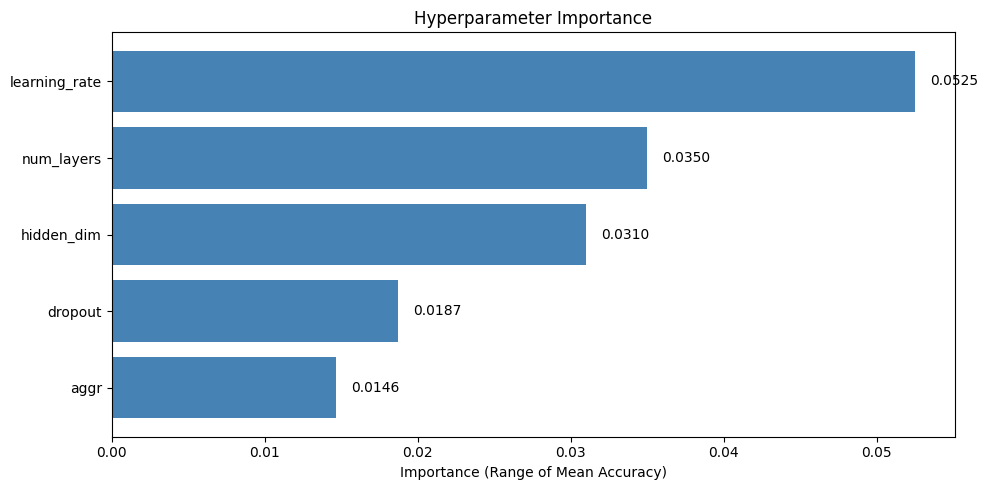


Plot saved to: ..\..\gSAGE\tuning\plots\hyperparameter_importance.png


In [4]:
# =============================================================================
# HYPERPARAMETER IMPORTANCE ANALYSIS
# =============================================================================

print("Hyperparameter Importance Analysis")
print("="*60)
print("\nMean validation accuracy by hyperparameter value:\n")

# Analyze each hyperparameter
hyperparams = ['hp_num_layers', 'hp_hidden_dim', 'hp_learning_rate', 'hp_dropout', 'hp_aggr']

importance_scores = {}

for hp in hyperparams:
    print(f"\n{hp.replace('hp_', '').upper()}:")
    grouped = df.groupby(hp)['val_accuracy'].agg(['mean', 'std', 'count'])
    grouped = grouped.sort_values('mean', ascending=False)

    # Calculate importance as range of means
    importance = grouped['mean'].max() - grouped['mean'].min()
    importance_scores[hp] = importance

    for idx, row in grouped.iterrows():
        print(f"  {idx}: mean={row['mean']:.4f}, std={row['std']:.4f}, n={int(row['count'])}")
    print(f"  Range: {importance:.4f}")

# Rank hyperparameters by importance
print(f"\n{'='*60}")
print("HYPERPARAMETER IMPORTANCE RANKING")
print("(by range of mean accuracy across values)")
print(f"{'='*60}")

sorted_importance = sorted(importance_scores.items(), key=lambda x: x[1], reverse=True)
for i, (hp, score) in enumerate(sorted_importance, 1):
    hp_name = hp.replace('hp_', '')
    print(f"{i}. {hp_name}: {score:.4f}")

# Plot importance
fig, ax = plt.subplots(figsize=(10, 5))
names = [hp.replace('hp_', '') for hp, _ in sorted_importance]
scores = [score for _, score in sorted_importance]
bars = ax.barh(names, scores, color='steelblue')
ax.set_xlabel('Importance (Range of Mean Accuracy)')
ax.set_title('Hyperparameter Importance')
ax.invert_yaxis()

# Add value labels
for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'hyperparameter_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to: {PLOTS_DIR / 'hyperparameter_importance.png'}")

#### Save Best Model Config

Save the best model configuration to a JSON file that can be loaded by other parts of the codebase.

In [5]:
# =============================================================================
# SAVE BEST MODEL CONFIG TO JSON
# =============================================================================

def save_best_config(df, output_path=None):
    """
    Save the best model configuration to a JSON file.
    
    Args:
        df: DataFrame with tuning results (sorted by val_accuracy descending)
        output_path: Path to save the JSON file (default: TUNING_DIR / 'best_model_config.json')
    
    Returns:
        Path to the saved config file
    """
    if output_path is None:
        output_path = TUNING_DIR / 'best_model_config.json'
    
    # Get the best configuration (first row, highest val_accuracy)
    best = df.iloc[0]
    
    config = {
        "description": "Best GraphSAGE model configuration from hyperparameter tuning",
        "config_id": int(best['config_id']),
        "generated_from": "tuning.ipynb",
        "generated_at": pd.Timestamp.now().isoformat(),
        
        "model_params": {
            "in_channels": 5,
            "hidden_dim": int(best['hp_hidden_dim']),
            "num_layers": int(best['hp_num_layers']),
            "dropout": float(best['hp_dropout']),
            "aggr": best['hp_aggr']
        },
        
        "training_params": {
            "learning_rate": float(best['hp_learning_rate']),
            "batch_size": 256,
            "epochs": 10,
            "distance": 7
        },
        
        "performance": {
            "val_accuracy": float(best['val_accuracy']),
            "test_accuracy": float(best['test_accuracy']),
            "final_loss": float(best['final_loss']),
            "training_time_sec": float(best['training_time_sec'])
        },
        
        "model_file": f"models/config_{int(best['config_id'])}.pt"
    }
    
    with open(output_path, 'w') as f:
        json.dump(config, f, indent=2)
    
    print(f"Best model config saved to: {output_path}")
    print(f"\nConfig ID: {config['config_id']}")
    print(f"Val Accuracy: {config['performance']['val_accuracy']:.4f}")
    print(f"Test Accuracy: {config['performance']['test_accuracy']:.4f}")
    print(f"\nModel parameters:")
    for k, v in config['model_params'].items():
        print(f"  {k}: {v}")
    
    return output_path

# Save the best config (assumes df is already loaded from combined_results.csv)
save_best_config(df)

Best model config saved to: ..\..\gSAGE\tuning\best_model_config.json

Config ID: 13
Val Accuracy: 0.9390
Test Accuracy: 0.9388

Model parameters:
  in_channels: 5
  hidden_dim: 256
  num_layers: 5
  dropout: 0.1
  aggr: max


WindowsPath('../../gSAGE/tuning/best_model_config.json')

#### Load Best Model

Use this cell to load a specific trained model for further use.

In [ ]:
# =============================================================================
# LOAD A SPECIFIC MODEL
# =============================================================================

def load_tuning_model(config_id):
    """Load a trained model from the tuning results."""
    model_path = MODELS_DIR / f"config_{config_id}.pt"

    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")

    # Load saved data
    save_dict = torch.load(model_path, map_location=device, weights_only=False)

    # Get hyperparameters
    hp = save_dict['hyperparams']
    config = save_dict['config']

    print(f"Loading model from config {config_id}")
    print(f"  Val Accuracy: {save_dict['val_accuracy']:.4f}")
    print(f"  Test Accuracy: {save_dict['test_accuracy']:.4f}")
    print(f"  Hyperparameters: layers={hp['num_layers']}, dim={hp['hidden_dim']}, "
          f"lr={hp['learning_rate']}, dropout={hp['dropout']}, aggr={hp['aggr']}")

    # Create model with correct architecture
    model = GraphSAGE(
        nickname=f"tuning_config_{config_id}",
        in_channels=config['in_channels'],
        hidden_dim=config['hidden_dim'],
        num_layers=config['num_layers'],
        dropout=config.get('dropout', 0.0),
        aggr=config.get('aggr', 'mean'),
        device=device,
        base_path=BASE_PATH
    )

    # Load weights
    model.model.load_state_dict(save_dict['state_dict'])
    model.model.eval()

    return model, save_dict

# Example: Load the best model (config ID from top of rankings)
# Uncomment and set the config_id to load:

# best_config_id = 0  # Replace with actual best config ID from analysis
# best_model, best_info = load_tuning_model(best_config_id)

# List available models
print("Available models:")
for model_file in sorted(MODELS_DIR.glob("config_*.pt")):
    print(f"  {model_file.name}")